In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from lifelines import CoxPHFitter
from lifelines import KaplanMeierFitter
from lifelines.utils import concordance_index

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:

PROJECT_DIR = Path(
    "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/brca_metabric"
)

DATA_FILE = (
    PROJECT_DIR
    / "processed_data"
    / "metabric_survival_cohort.csv"
)

df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (1981, 37)


,PATIENT_ID,LYMPH_NODES_EXAMINED_POSITIVE,NPI,CELLULARITY,CHEMOTHERAPY,COHORT,ER_IHC,HER2_SNP6,HORMONE_THERAPY,INFERRED_MENOPAUSAL_STATE,SEX,INTCLUST,AGE_AT_DIAGNOSIS,OS_MONTHS,OS_STATUS,CLAUDIN_SUBTYPE,THREEGENE,VITAL_STATUS,LATERALITY,RADIO_THERAPY,HISTOLOGICAL_SUBTYPE,BREAST_SURGERY,RFS_MONTHS,RFS_STATUS,SAMPLE_ID,CANCER_TYPE,CANCER_TYPE_DETAILED,ER_STATUS,HER2_STATUS,GRADE,ONCOTREE_CODE,PR_STATUS,SAMPLE_TYPE,TUMOR_SIZE,TUMOR_STAGE,TMB_NONSYNONYMOUS,EVENT
0,MB-0000,10.0,6.044,NaN,NO,1.0,Positve,NEUTRAL,YES,Post,Female,4ER+,75.65,140.500000,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.500000,0:Not Recurred,MB-0000,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3.0,IDC,Negative,Primary,22.0,2.0,0.000000,0
1,MB-0002,0.0,4.020,High,NO,1.0,Positve,NEUTRAL,YES,Pre,Female,4ER+,43.19,84.633333,0:LIVING,LumA,ER+/HER2- High Prolif,Living,Right,YES,Ductal/NST,BREAST CONSERVING,84.633333,0:Not Recurred,MB-0002,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3.0,IDC,Positive,Primary,10.0,1.0,2.615035,0
2,MB-0005,1.0,4.030,High,YES,1.0,Positve,NEUTRAL,YES,Pre,Female,3,48.87,163.700000,1:DECEASED,LumB,NaN,Died of Disease,Right,NO,Ductal/NST,MASTECTOMY,153.300000,1:Recurred,MB-0005,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,2.0,IDC,Positive,Primary,15.0,2.0,2.615035,1
3,MB-0006,3.0,4.050,Moderate,YES,1.0,Positve,NEUTRAL,YES,Pre,Female,9,47.68,164.933333,0:LIVING,LumB,NaN,Living,Right,YES,Mixed,MASTECTOMY,164.933333,0:Not Recurred,MB-0006,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,2.0,MDLC,Positive,Primary,25.0,2.0,1.307518,0
4,MB-0008,8.0,6.080,High,YES,1.0,Positve,NEUTRAL,YES,Post,Female,9,76.97,41.366667,1:DECEASED,LumB,ER+/HER2- High Prolif,Died of Disease,Right,YES,Mixed,MASTECTOMY,18.800000,1:Recurred,MB-0008,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,3.0,MDLC,Positive,Primary,40.0,2.0,2.615035,1


In [5]:

predictor_columns = [
    "AGE_AT_DIAGNOSIS",
    "TUMOR_SIZE",
    "GRADE",
    "LYMPH_NODES_EXAMINED_POSITIVE",
    "ER_STATUS"
]

outcome_columns = [
    "OS_MONTHS",
    "EVENT"
]

cox_df = df[
    predictor_columns + outcome_columns
].copy()

print("Initial Cox dataset shape:")

print(cox_df.shape)

display(cox_df.head())

Initial Cox dataset shape:
(1981, 7)


,AGE_AT_DIAGNOSIS,TUMOR_SIZE,GRADE,LYMPH_NODES_EXAMINED_POSITIVE,ER_STATUS,OS_MONTHS,EVENT
0,75.65,22.0,3.0,10.0,Positive,140.500000,0
1,43.19,10.0,3.0,0.0,Positive,84.633333,0
2,48.87,15.0,2.0,1.0,Positive,163.700000,1
3,47.68,25.0,2.0,3.0,Positive,164.933333,0
4,76.97,40.0,3.0,8.0,Positive,41.366667,1


In [7]:

missing_summary = pd.DataFrame({
    "Missing_Count": cox_df.isna().sum(),
    "Missing_Percentage": cox_df.isna().mean() * 100
})

display(
    missing_summary.sort_values(
        by="Missing_Percentage",
        ascending=False
    )
)

,Missing_Count,Missing_Percentage
GRADE,88,4.442201
LYMPH_NODES_EXAMINED_POSITIVE,76,3.836446
TUMOR_SIZE,26,1.312468
AGE_AT_DIAGNOSIS,0,0.000000
ER_STATUS,0,0.000000
OS_MONTHS,0,0.000000
EVENT,0,0.000000


In [9]:

cox_complete = cox_df.dropna().copy()

cox_complete = cox_complete[
    cox_complete["OS_MONTHS"] > 0
].copy()

print(
    "Original patients:",
    len(cox_df)
)

print(
    "Patients retained:",
    len(cox_complete)
)

print(
    "Patients excluded:",
    len(cox_df) - len(cox_complete)
)

print("\nEvent distribution:")

print(
    cox_complete["EVENT"].value_counts()
)

Original patients: 1981
Patients retained: 1816
Patients excluded: 165

Event distribution:
EVENT
1    1042
0     774
Name: count, dtype: int64


In [11]:

cox_complete["ER_POSITIVE"] = (
    cox_complete["ER_STATUS"]
    .map({
        "Negative": 0,
        "Positive": 1
    })
)

assert cox_complete["ER_POSITIVE"].notna().all()

cox_complete = cox_complete.drop(
    columns=["ER_STATUS"]
)

print(
    cox_complete["ER_POSITIVE"].value_counts()
)

display(cox_complete.head())

ER_POSITIVE
1    1385
0     431
Name: count, dtype: int64


,AGE_AT_DIAGNOSIS,TUMOR_SIZE,GRADE,LYMPH_NODES_EXAMINED_POSITIVE,OS_MONTHS,EVENT,ER_POSITIVE
0,75.65,22.0,3.0,10.0,140.500000,0,1
1,43.19,10.0,3.0,0.0,84.633333,0,1
2,48.87,15.0,2.0,1.0,163.700000,1,1
3,47.68,25.0,2.0,3.0,164.933333,0,1
4,76.97,40.0,3.0,8.0,41.366667,1,1


In [13]:

cox_age = CoxPHFitter()

cox_age.fit(
    cox_complete[
        [
            "AGE_AT_DIAGNOSIS",
            "OS_MONTHS",
            "EVENT"
        ]
    ],
    duration_col="OS_MONTHS",
    event_col="EVENT"
)

cox_age.print_summary()

<lifelines.CoxPHFitter: fitted with 1816 total observations, 774 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'EVENT'
      baseline estimation = breslow
   number of observations = 1816
number of events observed = 1042
   partial log-likelihood = -6993.10
         time fit was run = 2026-09-22 18:36:22 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
AGE_AT_DIAGNOSIS  0.03      1.04      0.00            0.03            0.04                1.03                1.04

                  cmp to     z      p  -log2(p)
covariate                                      
AGE_AT_DIAGNOSIS    0.00 12.82 <0.005    122.65
---
Concordance = 0.59
Partial AIC = 13988.21
log-likelihood ratio test = 172.96 on 1 df
-log2(p) of ll-ratio test = 128.82

In [15]:

cox_model = CoxPHFitter(
    penalizer=0.01
)

cox_model.fit(
    cox_complete,
    duration_col="OS_MONTHS",
    event_col="EVENT"
)

cox_model.print_summary()

<lifelines.CoxPHFitter: fitted with 1816 total observations, 774 right-censored observations>
             duration col = 'OS_MONTHS'
                event col = 'EVENT'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1816
number of events observed = 1042
   partial log-likelihood = -6904.93
         time fit was run = 2026-09-22 18:36:31 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
AGE_AT_DIAGNOSIS               0.04      1.04      0.00            0.03            0.04                1.03                1.04
TUMOR_SIZE                     0.01      1.01      0.00            0.01            0.01                1.01                1.01
GRADE                          0.15      1.16      0.05            0.04            0.25                1.05                1.29
LYMPH_NODES_EXAMINED_POSITIVE  0.05      1.06      0.01            0.04            0.07                1.05                1.07
ER_POSITIVE                   -0.33      0.72      0.08           -0.49           -0.17                0.62                0.84

                               cmp to     z      p  -log2(p)
covariate                                                   
AGE_AT_DIAGNOSIS                 0.00 13.54 <0.005    136.40
TUMOR_SIZE                       0.00  6.93 <0.005     37.74
GRADE                            0.00  2.80   0.01      7.60
LYMPH_NODES_EXAMINED_POSITIVE    0.00  9.95 <0.005     75.04
ER_POSITIVE                      0.00 -4.09 <0.005     14.49
---
Concordance = 0.66
Partial AIC = 13819.87
log-likelihood ratio test = 349.30 on 5 df
-log2(p) of ll-ratio test = 241.19

In [17]:

cox_results = cox_model.summary[
    [
        "coef",
        "exp(coef)",
        "exp(coef) lower 95%",
        "exp(coef) upper 95%",
        "p"
    ]
].copy()

cox_results = cox_results.rename(
    columns={
        "coef": "Coefficient",
        "exp(coef)": "Hazard_Ratio",
        "exp(coef) lower 95%": "CI_Lower",
        "exp(coef) upper 95%": "CI_Upper",
        "p": "P_Value"
    }
)

display(cox_results.round(4))

,Coefficient,Hazard_Ratio,CI_Lower,CI_Upper,P_Value
covariate,,,,,
AGE_AT_DIAGNOSIS,0.0373,1.0380,1.0325,1.0437,0.0000
TUMOR_SIZE,0.0109,1.0110,1.0079,1.0141,0.0000
GRADE,0.1482,1.1598,1.0454,1.2867,0.0052
LYMPH_NODES_EXAMINED_POSITIVE,0.0550,1.0565,1.0451,1.0680,0.0000
ER_POSITIVE,-0.3279,0.7204,0.6156,0.8431,0.0000


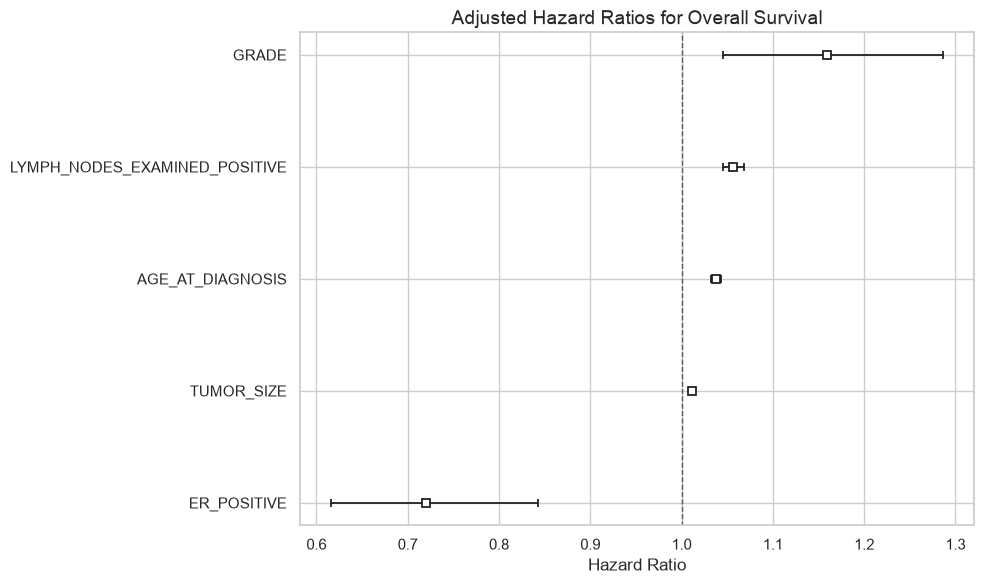

In [19]:

fig, ax = plt.subplots(figsize=(10, 6))

cox_model.plot(
    ax=ax,
    hazard_ratios=True
)

ax.set_title(
    "Adjusted Hazard Ratios for Overall Survival",
    fontsize=14
)

ax.set_xlabel("Hazard Ratio")

plt.tight_layout()

plt.show()

In [21]:

c_index = cox_model.concordance_index_

print(
    "Cox model concordance index:",
    round(c_index, 4)
)

Cox model concordance index: 0.6599



   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'AGE_AT_DIAGNOSIS' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'AGE_AT_DIAGNOSIS' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'AGE_AT_DIAGNOSIS' using pd.cut, and then specify it in
`strata=['AGE_AT_DIAGNOSIS', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


2. Variable 'GRADE' failed the non-proportional test: p-value is 0.0133.

   Advice: with so few unique values (only 3), you can include `strata=['GRADE', ...]` in the call
in `.fit`. See documentation in link [E] 

[[<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9283)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0133)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0135)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1190)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2078)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>]]

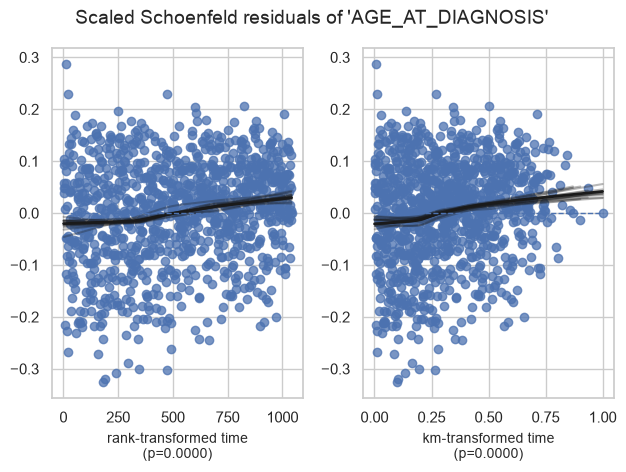

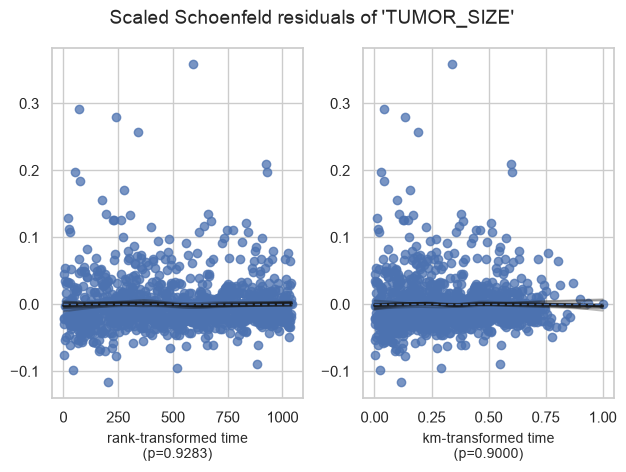

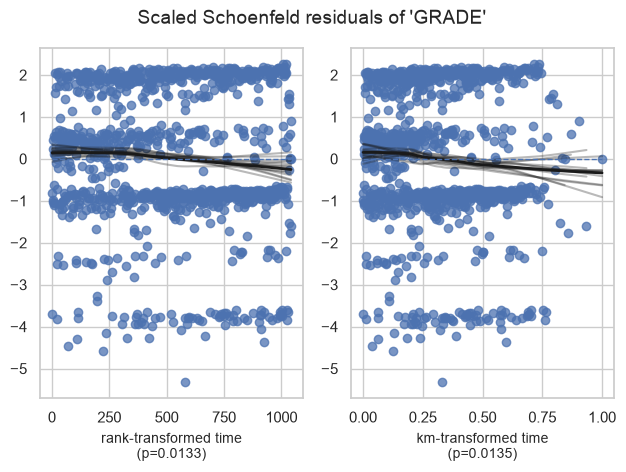

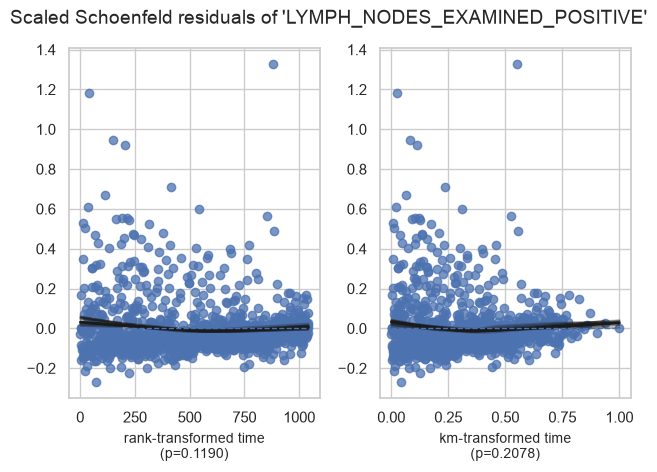

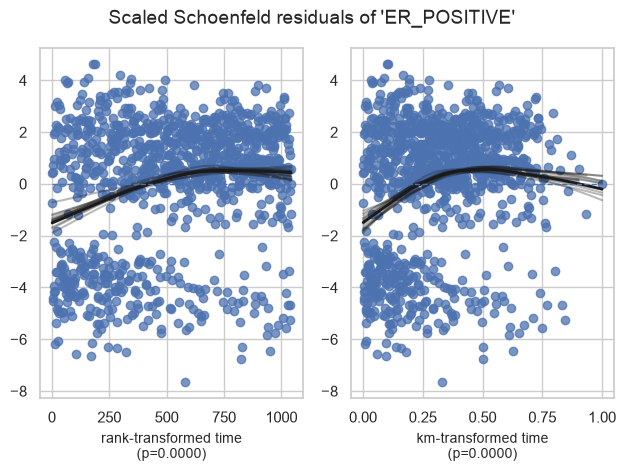

In [23]:

cox_model.check_assumptions(
    cox_complete,
    p_value_threshold=0.05,
    show_plots=True
)

In [25]:

RESULTS_DIR = PROJECT_DIR / "results"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

cox_results.to_csv(
    RESULTS_DIR / "cox_regression_results.csv"
)

cox_complete.to_csv(
    RESULTS_DIR / "cox_complete_case_dataset.csv",
    index=False
)

print("Cox regression results saved successfully!")

Cox regression results saved successfully!


In [27]:

stratified_df = cox_complete.copy()

stratified_df["GRADE"] = (
    stratified_df["GRADE"].astype(int)
)

stratified_df["ER_POSITIVE"] = (
    stratified_df["ER_POSITIVE"].astype(int)
)

print("Dataset shape:", stratified_df.shape)

print("\nGrade distribution:")
print(stratified_df["GRADE"].value_counts())

print("\nER status distribution:")
print(stratified_df["ER_POSITIVE"].value_counts())

print("\nPatients by grade and ER status:")

display(
    pd.crosstab(
        stratified_df["GRADE"],
        stratified_df["ER_POSITIVE"]
    )
)

Dataset shape: (1816, 7)

Grade distribution:
GRADE
3    921
2    732
1    163
Name: count, dtype: int64

ER status distribution:
ER_POSITIVE
1    1385
0     431
Name: count, dtype: int64

Patients by grade and ER status:


ER_POSITIVE,0,1
GRADE,,
1,3,160
2,55,677
3,373,548


In [29]:

stratified_cox = CoxPHFitter(
    penalizer=0.01
)

stratified_cox.fit(
    stratified_df,
    duration_col="OS_MONTHS",
    event_col="EVENT",
    strata=["GRADE", "ER_POSITIVE"]
)

stratified_cox.print_summary()

model,lifelines.CoxPHFitter
duration col,'OS_MONTHS'
event col,'EVENT'
penalizer,0.01
l1 ratio,0.0
strata,"[GRADE, ER_POSITIVE]"
baseline estimation,breslow
number of observations,1816
number of events observed,1042
partial log-likelihood,-5504.14
time fit was run,2026-09-22 18:40:12 UTC


In [31]:

stratified_results = stratified_cox.summary[
    [
        "coef",
        "exp(coef)",
        "exp(coef) lower 95%",
        "exp(coef) upper 95%",
        "p"
    ]
].copy()

stratified_results = stratified_results.rename(
    columns={
        "coef": "Coefficient",
        "exp(coef)": "Hazard_Ratio",
        "exp(coef) lower 95%": "CI_Lower",
        "exp(coef) upper 95%": "CI_Upper",
        "p": "P_Value"
    }
)

display(stratified_results.round(4))

,Coefficient,Hazard_Ratio,CI_Lower,CI_Upper,P_Value
covariate,,,,,
AGE_AT_DIAGNOSIS,0.0375,1.0382,1.0326,1.0438,0.0
TUMOR_SIZE,0.0111,1.0111,1.0080,1.0143,0.0
LYMPH_NODES_EXAMINED_POSITIVE,0.0535,1.0549,1.0435,1.0664,0.0


In [33]:

comparison_df = pd.DataFrame({
    "Model": [
        "Original Cox Model",
        "Stratified Cox Model"
    ],
    "Training_C_Index": [
        cox_model.concordance_index_,
        stratified_cox.concordance_index_
    ]
})

display(comparison_df.round(4))

,Model,Training_C_Index
0,Original Cox Model,0.6599
1,Stratified Cox Model,0.6604



   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'AGE_AT_DIAGNOSIS' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'AGE_AT_DIAGNOSIS' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'AGE_AT_DIAGNOSIS' using pd.cut, and then specify it in
`strata=['AGE_AT_DIAGNOSIS', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


2. Variable 'LYMPH_NODES_EXAMINED_POSITIVE' failed the non-proportional test: p-value is 0.0028.

   Advice 1: the functional form of the variable 'LYMPH_NODES_EXAMINED_POSITIVE' might be incorrect.
That is, there 

[[<Axes: xlabel='rank-transformed time\n(p=0.0815)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8233)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9745)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0028)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3133)'>]]

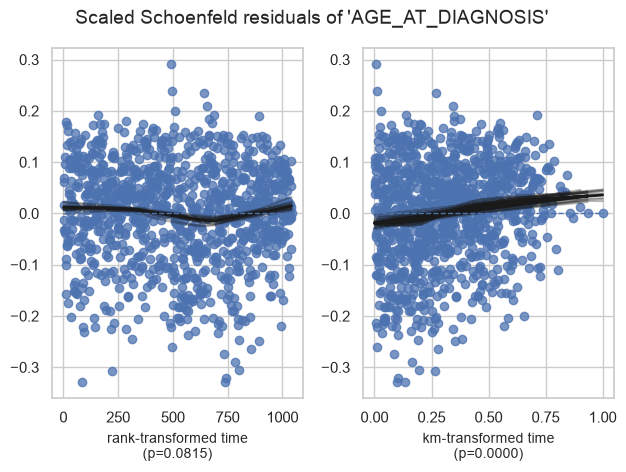

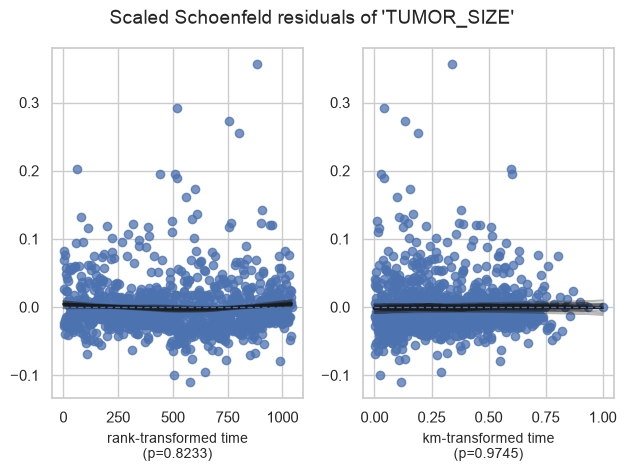

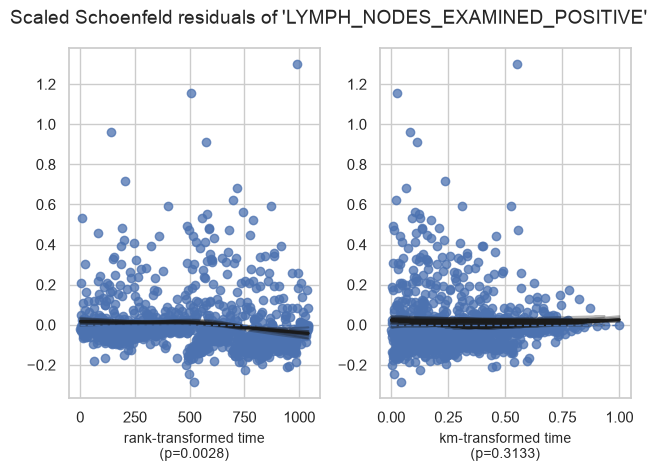

In [35]:

stratified_cox.check_assumptions(
    stratified_df,
    p_value_threshold=0.05,
    show_plots=True
)

In [37]:

stratified_results.to_csv(
    RESULTS_DIR / "stratified_cox_results.csv"
)

comparison_df.to_csv(
    RESULTS_DIR / "cox_model_comparison.csv",
    index=False
)

print("Stratified Cox results saved successfully!")

Stratified Cox results saved successfully!


In [39]:

spline_df = stratified_df.copy()

spline_cox = CoxPHFitter(
    penalizer=0.01
)

spline_cox.fit(
    spline_df,
    duration_col="OS_MONTHS",
    event_col="EVENT",
    strata=["GRADE", "ER_POSITIVE"],
    formula=(
        "bs(AGE_AT_DIAGNOSIS, df=4) + "
        "bs(LYMPH_NODES_EXAMINED_POSITIVE, df=4) + "
        "TUMOR_SIZE"
    )
)

spline_cox.print_summary()

model,lifelines.CoxPHFitter
duration col,'OS_MONTHS'
event col,'EVENT'
penalizer,0.01
l1 ratio,0.0
strata,"[GRADE, ER_POSITIVE]"
baseline estimation,breslow
number of observations,1816
number of events observed,1042
partial log-likelihood,-5468.06
time fit was run,2026-09-22 18:43:02 UTC



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.3017)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6198)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1423)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1220)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5235)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1856)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1863)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6493)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9655)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9077)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9827)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7125)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7765)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5823)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6625)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8360)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8415)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6900)'>]]

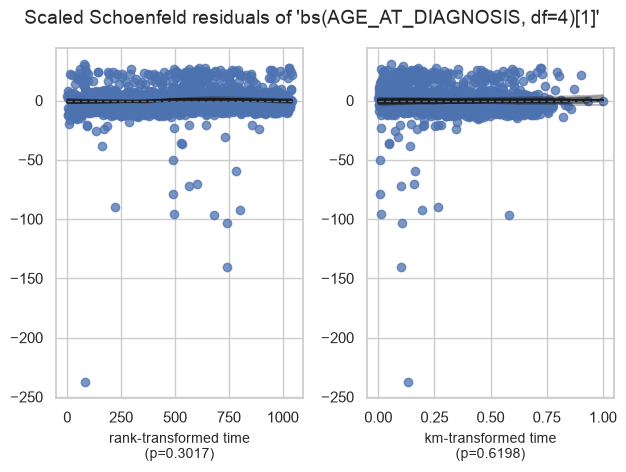

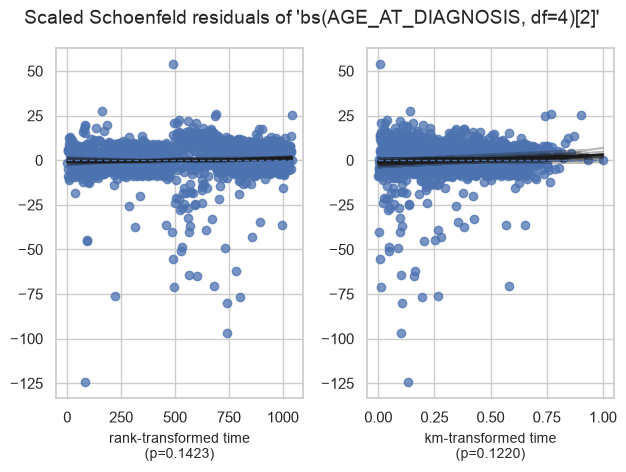

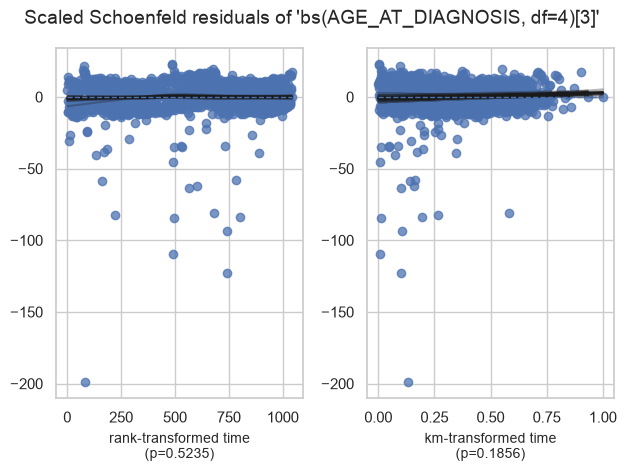

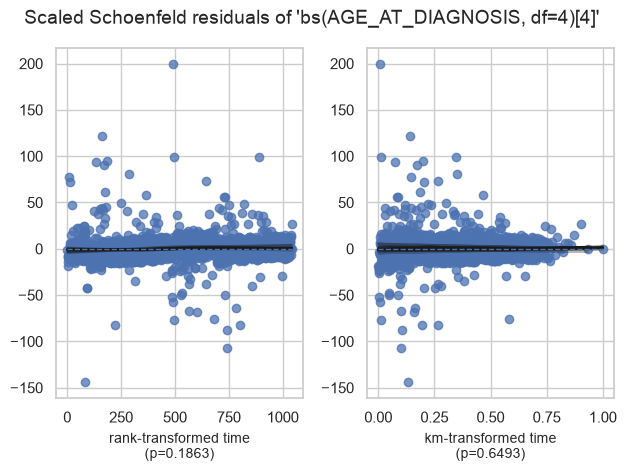

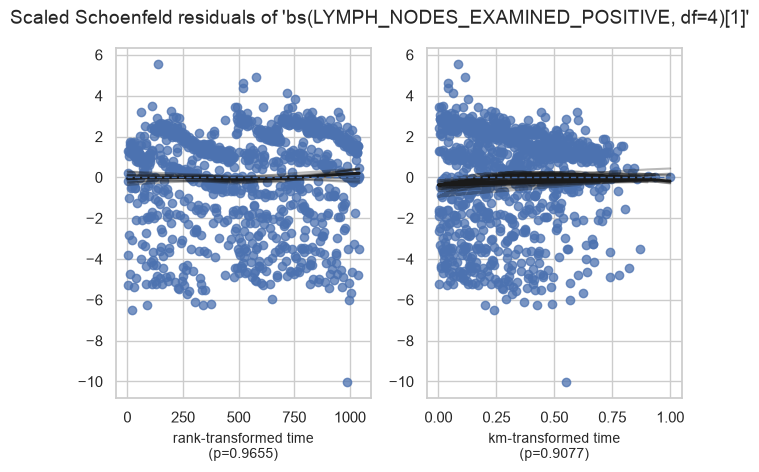

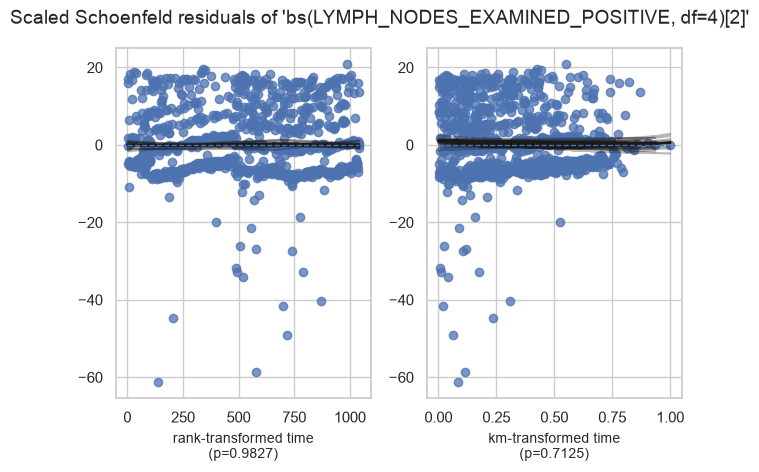

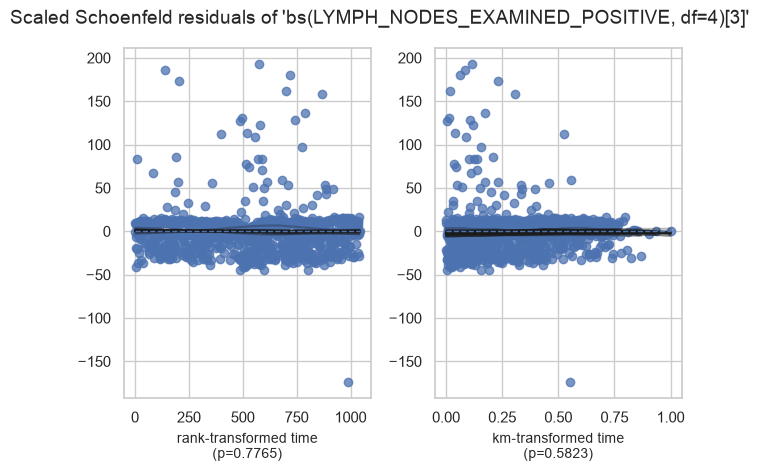

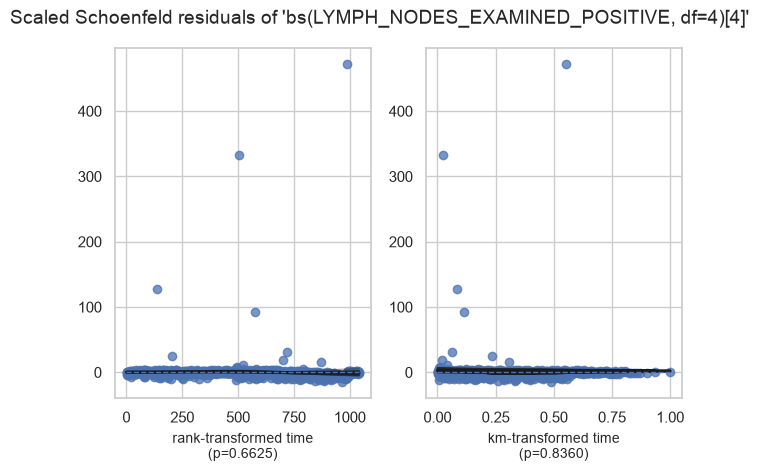

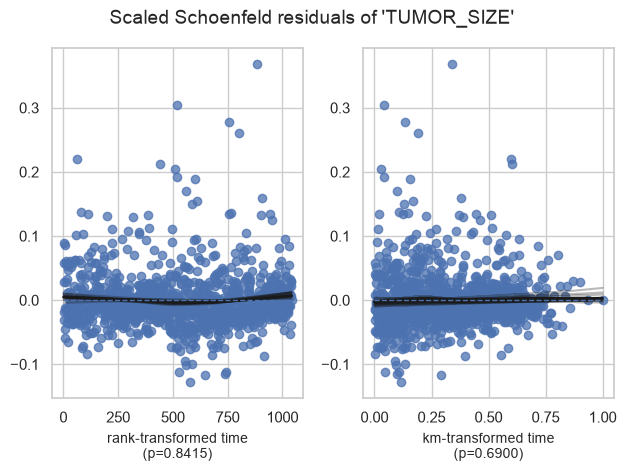

In [45]:

spline_cox.check_assumptions(
    spline_df,
    p_value_threshold=0.05,
    show_plots=True
)

In [49]:

model_comparison = pd.DataFrame({
    "Model": [
        "Original Cox",
        "Stratified Cox",
        "Stratified Cox with Splines"
    ],
    "Training_C_Index": [
        cox_model.concordance_index_,
        stratified_cox.concordance_index_,
        spline_cox.concordance_index_
    ],
    "Partial_AIC": [
        cox_model.AIC_partial_,
        stratified_cox.AIC_partial_,
        spline_cox.AIC_partial_
    ]
})

display(model_comparison.round(4))

,Model,Training_C_Index,Partial_AIC
0,Original Cox,0.6599,13819.8693
1,Stratified Cox,0.6604,11014.2729
2,Stratified Cox with Splines,0.6731,10954.1213


<Figure size 1000x600 with 0 Axes>

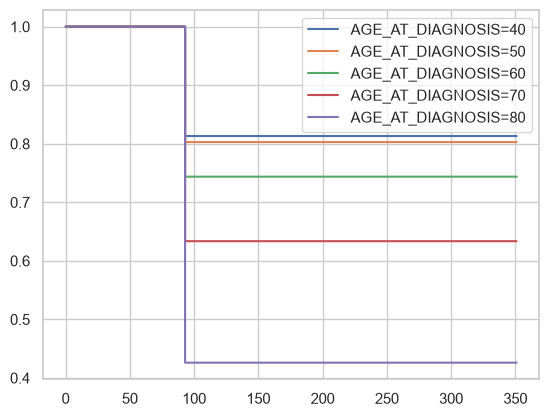

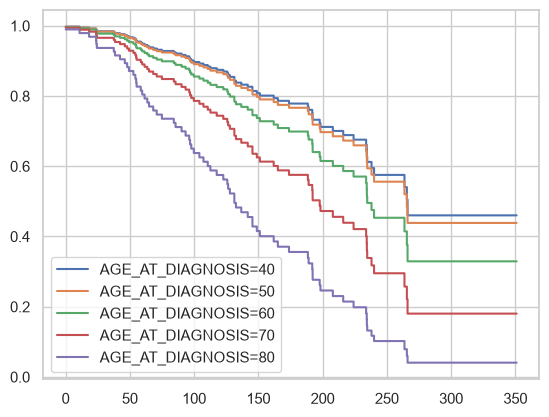

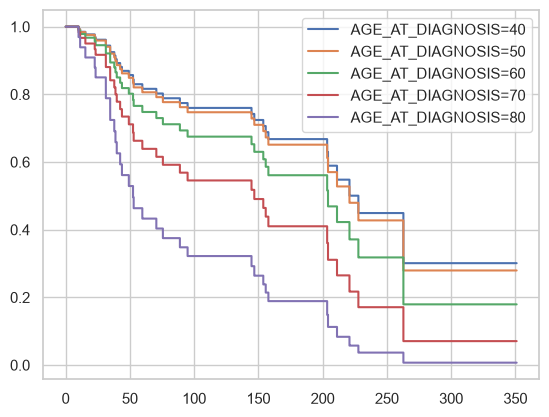

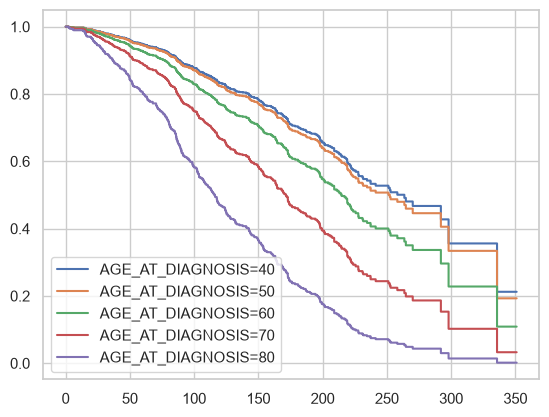

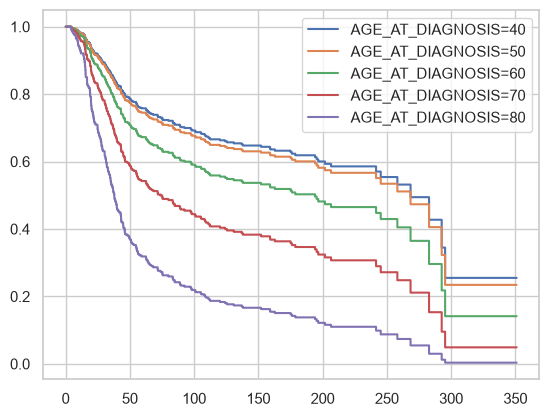

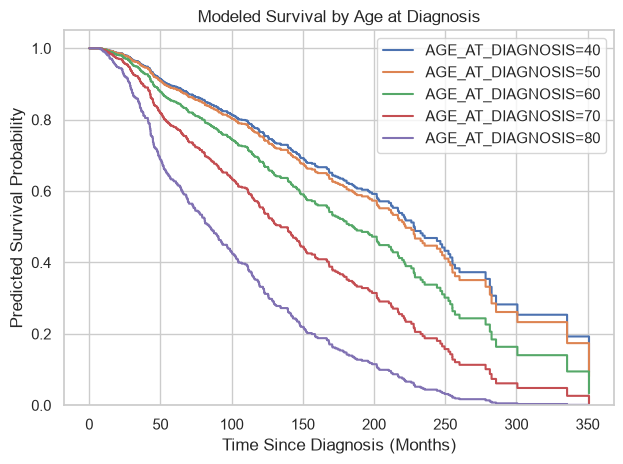

In [53]:

plt.figure(figsize=(10, 6))

spline_cox.plot_partial_effects_on_outcome(
    covariates="AGE_AT_DIAGNOSIS",
    values=[40, 50, 60, 70, 80],
    plot_baseline=False,
    y="survival_function"
)

plt.title("Modeled Survival by Age at Diagnosis")

plt.xlabel("Time Since Diagnosis (Months)")

plt.ylabel("Predicted Survival Probability")

plt.ylim(0, 1.05)

plt.tight_layout()

plt.show()

In [55]:

spline_cox.summary.to_csv(
    RESULTS_DIR / "cox_spline_model_results.csv"
)

model_comparison.to_csv(
    RESULTS_DIR / "cox_extended_model_comparison.csv",
    index=False
)

print("Extended Cox analysis saved successfully!")

Extended Cox analysis saved successfully!
